## Daily Challenge

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import ttest_ind

In [4]:
print("Loading Dataset...\n")

df = pd.read_csv(
    "data/Airplane_Crashes_and_Fatalities_Since_1908_t0_2023.csv",
    encoding="latin1"
)

print("Dataset Loaded Successfully!\n")

Loading Dataset...

Dataset Loaded Successfully!



In [5]:
print("First 5 Rows:\n")
print(df.head())

First 5 Rows:

        Date   Time                            Location  \
0  9/17/1908  17:18                 Fort Myer, Virginia   
1   9/7/1909    NaN             Juvisy-sur-Orge, France   
2  7/12/1912   6:30           Atlantic City, New Jersey   
3   8/6/1913    NaN  Victoria, British Columbia, Canada   
4   9/9/1913  18:30                  Over the North Sea   

                 Operator Flight #          Route                 AC Type  \
0    Military - U.S. Army      NaN  Demonstration        Wright Flyer III   
1                     NaN      NaN       Air show          Wright Byplane   
2    Military - U.S. Navy      NaN    Test flight               Dirigible   
3                 Private      NaN            NaN        Curtiss seaplane   
4  Military - German Navy      NaN            NaN  Zeppelin L-1 (airship)   

  Registration cn/ln  Aboard  Aboard Passangers  Aboard Crew  Fatalities  \
0          NaN     1     2.0                1.0          1.0         1.0   
1          SC1 

In [6]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(4998, 17)


In [7]:
print("Dataset Information:\n")
print(df.info())

Dataset Information:

<class 'pandas.DataFrame'>
RangeIndex: 4998 entries, 0 to 4997
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   4998 non-null   str    
 1   Time                   3486 non-null   str    
 2   Location               4994 non-null   str    
 3   Operator               4988 non-null   str    
 4   Flight #               1329 non-null   str    
 5   Route                  4221 non-null   str    
 6   AC Type                4983 non-null   str    
 7   Registration           4724 non-null   str    
 8   cn/ln                  4330 non-null   str    
 9   Aboard                 4980 non-null   float64
 10  Aboard Passangers      4769 non-null   float64
 11  Aboard Crew            4772 non-null   float64
 12  Fatalities             4990 non-null   float64
 13  Fatalities Passangers  4756 non-null   float64
 14  Fatalities Crew        4757 non-null   float6

In [8]:
print("Statistical Summary:\n")
print(df.describe())

Statistical Summary:

            Aboard  Aboard Passangers  Aboard Crew   Fatalities  \
count  4980.000000        4769.000000  4772.000000  4990.000000   
mean     31.195984          27.009017     4.479254    22.373547   
std      45.534788          44.111609     3.483859    35.061741   
min       0.000000           0.000000     0.000000     0.000000   
25%       7.000000           3.000000     2.000000     4.000000   
50%      16.000000          12.000000     4.000000    11.000000   
75%      35.000000          30.000000     6.000000    25.000000   
max     644.000000         614.000000    61.000000   583.000000   

       Fatalities Passangers  Fatalities Crew       Ground  
count            4756.000000      4757.000000  4956.000000  
mean               19.053827         3.578516     1.719128  
std                34.146127         3.167922    55.540273  
min                 0.000000         0.000000     0.000000  
25%                 1.000000         2.000000     0.000000  
50%     

In [10]:
# Calculating variance for the 'Fatalities' column
fatalities_variance = df['Fatalities'].var()
print(f"Variance of Fatalities: {fatalities_variance}")

Variance of Fatalities: 1229.3256580910868


In [17]:
print("\nDATA CLEANING \n")

print("Missing Values:\n")
print(df.isnull().sum())

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

df["Year"] = df["Date"].dt.year

numerical_columns = ["Aboard", "Fatalities", "Ground"]

for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

categorical_columns = ["Operator", "Location", "Route", "AC Type"]

for col in categorical_columns:
    df[col] = df[col].fillna("Unknown")

print("\nData Cleaning Completed!")


DATA CLEANING 

Missing Values:

Date                        0
Time                     1512
Location                    0
Operator                    0
Flight #                 3669
Route                       0
AC Type                     0
Registration              274
cn/ln                     668
Aboard                      0
Aboard Passangers         229
Aboard Crew               226
Fatalities                  0
Fatalities Passangers     242
Fatalities Crew           241
Ground                      0
Summary                    64
Year                        0
dtype: int64

Data Cleaning Completed!


In [19]:
df["Survival_Rate"] = (
    (df["Aboard"] - df["Fatalities"]) / df["Aboard"]
) * 100

df["Survival_Rate"] = df["Survival_Rate"].replace(
    [np.inf, -np.inf],
    np.nan
)

df["Survival_Rate"] = df["Survival_Rate"].fillna(0)

print("\nSurvival Rate Added Successfully!")


Survival Rate Added Successfully!


In [21]:
print("Total Number of Crashes:", len(df))

print("\nTotal Fatalities:", df["Fatalities"].sum())

print("\nAverage Fatalities:", df["Fatalities"].mean())

print("\nAverage Survival Rate:", df["Survival_Rate"].mean())


Total Number of Crashes: 4998

Total Fatalities: 111732.0

Average Fatalities: 22.35534213685474

Average Survival Rate: 18.21169211025915


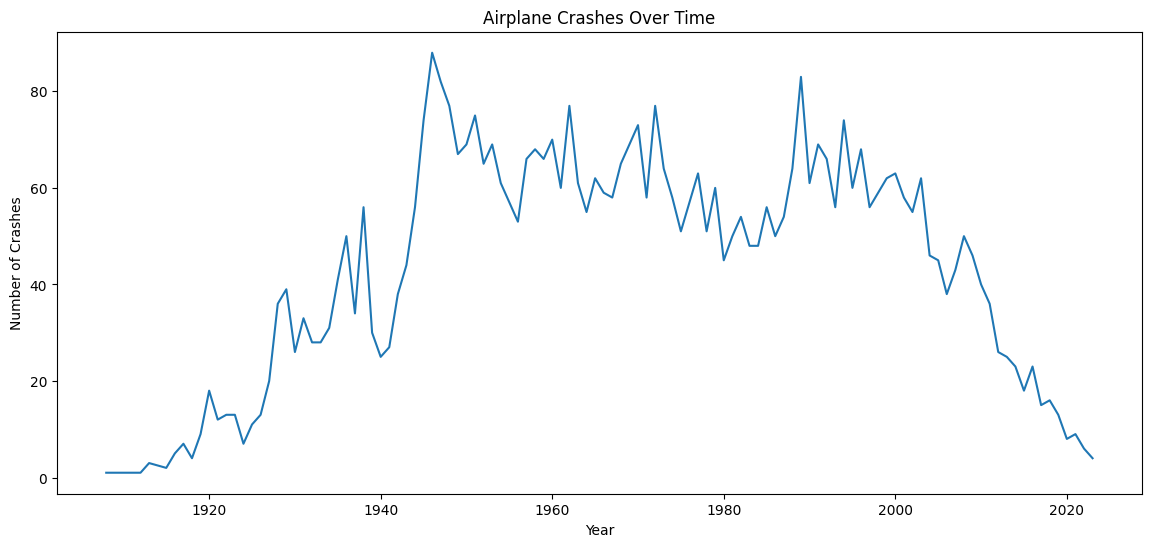

In [22]:
crashes_per_year = df.groupby("Year").size()

plt.figure(figsize=(14,6))
plt.plot(crashes_per_year)

plt.title("Airplane Crashes Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Crashes")

plt.show()

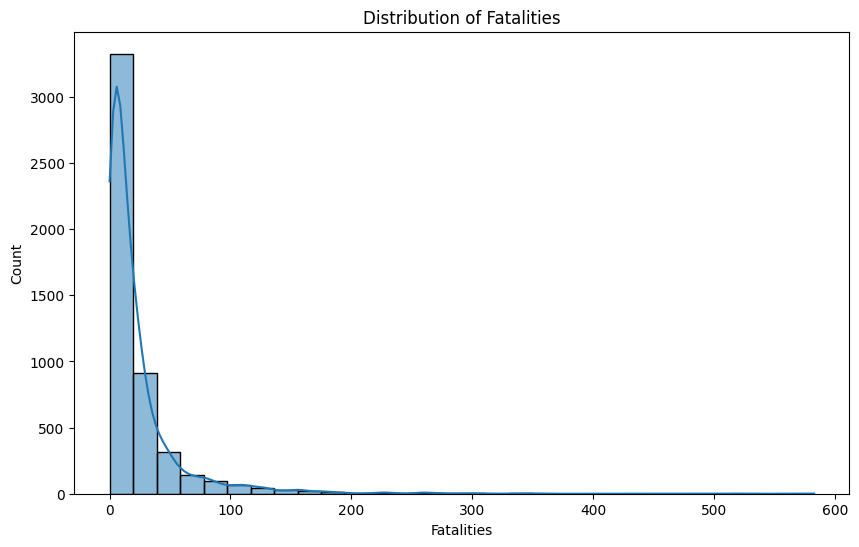

In [23]:
plt.figure(figsize=(10,6))

sns.histplot(df["Fatalities"], bins=30, kde=True)

plt.title("Distribution of Fatalities")
plt.xlabel("Fatalities")

plt.show()

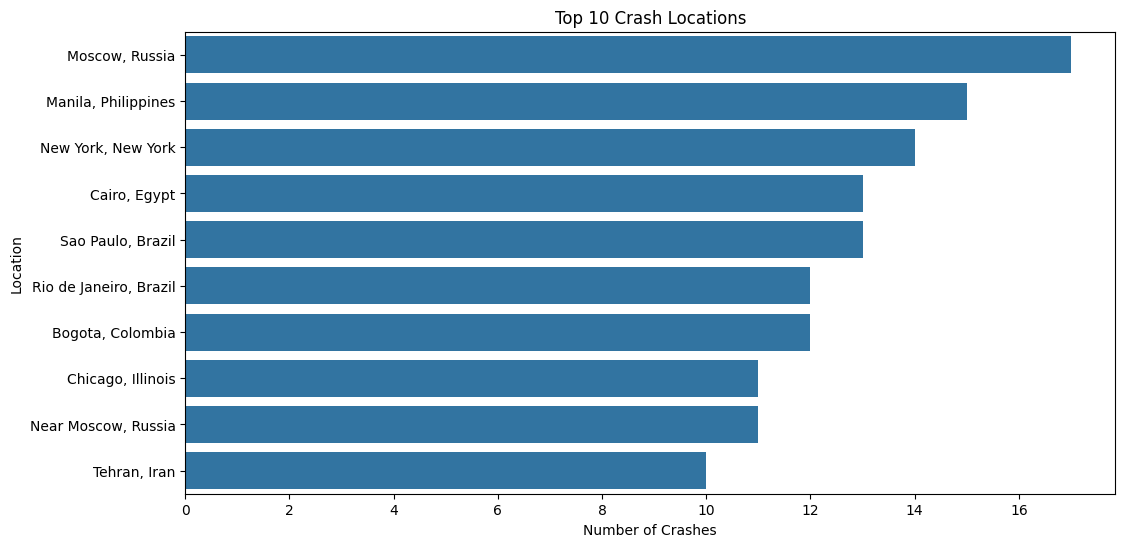

In [24]:
top_locations = df["Location"].value_counts().head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_locations.values,
    y=top_locations.index
)

plt.title("Top 10 Crash Locations")
plt.xlabel("Number of Crashes")

plt.show()

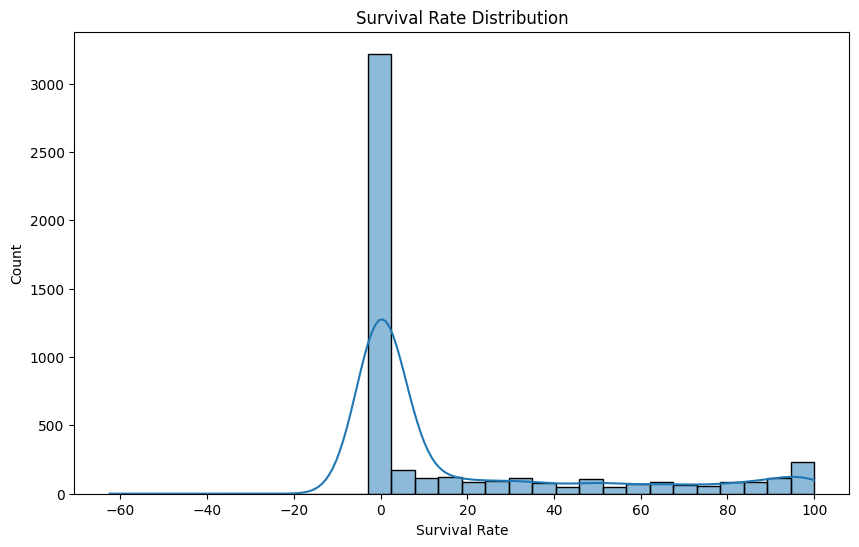

In [25]:
plt.figure(figsize=(10,6))

sns.histplot(df["Survival_Rate"], bins=30, kde=True)

plt.title("Survival Rate Distribution")
plt.xlabel("Survival Rate")

plt.show()

In [26]:
print("\n STATISTICAL ANALYSIS \n")

fatalities_mean = np.mean(df["Fatalities"])
fatalities_median = np.median(df["Fatalities"])
fatalities_std = np.std(df["Fatalities"])

print("Mean Fatalities:", fatalities_mean)
print("Median Fatalities:", fatalities_median)
print("Standard Deviation:", fatalities_std)


 STATISTICAL ANALYSIS 

Mean Fatalities: 22.35534213685474
Median Fatalities: 11.0
Standard Deviation: 35.033108768092106


In [27]:
before_1980 = df[df["Year"] < 1980]["Fatalities"]
after_1980 = df[df["Year"] >= 1980]["Fatalities"]

t_stat, p_value = ttest_ind(
    before_1980,
    after_1980,
    equal_var=False
)

print("\nT-Test Results")
print("T-Statistic:", t_stat)
print("P-Value:", p_value)

if p_value < 0.05:
    print("There is a significant difference in fatalities.")
else:
    print("There is no significant difference in fatalities.")



T-Test Results
T-Statistic: -5.761696102247421
P-Value: 9.188952622805846e-09
There is a significant difference in fatalities.


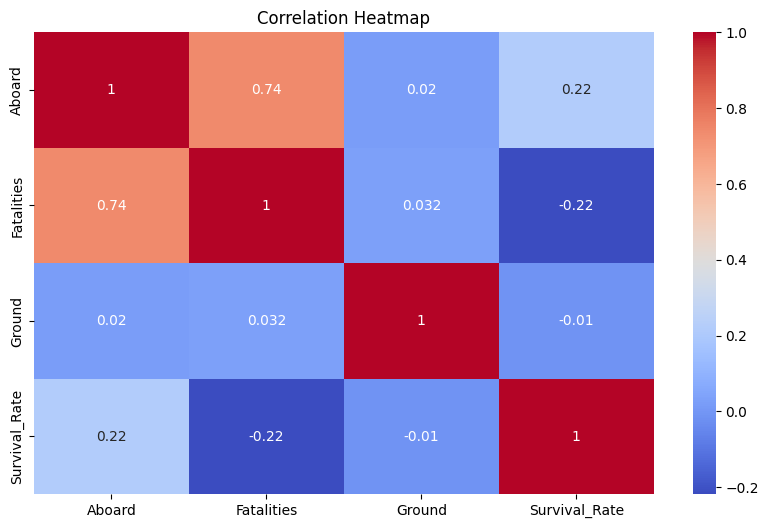

In [28]:
plt.figure(figsize=(10,6))

correlation = df[
    ["Aboard", "Fatalities", "Ground", "Survival_Rate"]
].corr()

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

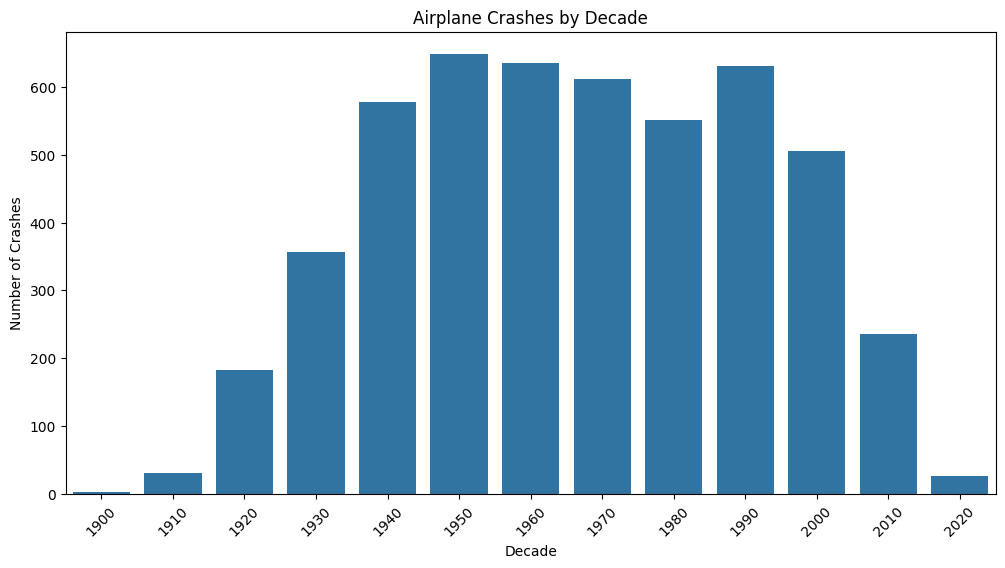

In [29]:
df["Decade"] = (df["Year"] // 10) * 10

decade_counts = df["Decade"].value_counts().sort_index()

plt.figure(figsize=(12,6))

sns.barplot(
    x=decade_counts.index,
    y=decade_counts.values
)

plt.title("Airplane Crashes by Decade")
plt.xlabel("Decade")
plt.ylabel("Number of Crashes")

plt.xticks(rotation=45)

plt.show()

In [30]:
print("\n FINAL INSIGHTS \n")

print("""
1. The dataset contains airplane crashes from 1908 to 2023.

2. Some years experienced more crashes than others.

3. Fatalities vary greatly between crashes.

4. Survival rates improved in some modern periods.

5. Certain locations recorded more crashes.

6. Statistical testing helped compare fatalities across time periods.

7. Data visualization made trends easier to understand.
""")



 FINAL INSIGHTS 


1. The dataset contains airplane crashes from 1908 to 2023.

2. Some years experienced more crashes than others.

3. Fatalities vary greatly between crashes.

4. Survival rates improved in some modern periods.

5. Certain locations recorded more crashes.

6. Statistical testing helped compare fatalities across time periods.

7. Data visualization made trends easier to understand.

